In [ ]:
# Title: 01_McKay_ElasticNet.ipynb
# Author: Lajoyce Mboning
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the EN clock on McKay et al

# Set Up

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#from sklearn.linear_model import LassoCV
from numpy import arange
from numpy import absolute
from numpy import mean
from numpy import std
import numpy as np
from scipy import stats
from sklearn.metrics import mean_absolute_error as mae
import statsmodels.api as sm
from scipy.stats import spearmanr
lowess = sm.nonparametric.lowess
from scipy.stats import poisson
from scipy.stats import pearsonr
from datetime import datetime
import time
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

In [ ]:
from numpy import mean
from numpy import std
from numpy import absolute
import pandas as pd
# use automatically configured elastic net algorithm
from numpy import arange
from sklearn.model_selection import cross_val_score
#from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import ElasticNet
#from sklearn.linear_model import ElasticNet
from sklearn.model_selection import RepeatedKFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
import statsmodels.api as sm
lowess = sm.nonparametric.lowess
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from scipy import stats

In [ ]:
#allow Google CoLab to have access to your drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# set working dir
# Get current notebook's directory
notebook_dir = '/content/drive/My Drive/african_killifish_atlas/revisions/CodeCheck_revisions/McKay_model_outputs/ElasticNet/'

# Set working directory (here it's just confirming it's already set)
os.chdir(notebook_dir)

# Load and format intervention data

In [ ]:
df_cr = pd.read_csv("../../Data_from_Others/ALDR/GSE216369_CountsNormDESeq2_Liver_ALDR_220331.csv")

df_cr.head(5)

,f_AL_L_1,m_AL_L_1,m_DR_L_1,f_AL_L_2,f_DR_L_1,m_AL_L_2,m_DR_L_2,f_DR_L_2,f_AL_L_3,m_DR_L_3,f_AL_L_4,f_DR_L_3,m_AL_L_3,m_DR_L_4,f_DR_L_4,m_AL_L_4
LOC107375582,1.065663,1.024315,0.951840,1.682535,0.826384,0.980873,2.279668,1.071467,1.053069,3.387973,1.044274,1.253454,0.920191,0.822090,1.170773,0.962468
LOC107388276,1.065663,6.145888,0.951840,1.682535,0.826384,0.980873,0.759889,1.071467,1.053069,1.129324,1.044274,1.253454,2.760574,0.822090,1.170773,6.737274
LOC107382448,2.131327,1.024315,0.951840,1.682535,0.826384,0.980873,0.759889,1.071467,1.053069,1.129324,1.044274,1.253454,0.920191,0.822090,1.170773,0.962468
LOC107377727,188.622436,35.851012,16.181281,11.777742,15.701294,26.483570,11.398339,39.644275,35.804344,5.646621,109.648747,43.870890,0.920191,2.466270,71.417142,28.874033
pex1,152.389878,382.069355,357.891867,215.364425,376.831063,225.600785,373.865526,259.294991,354.884231,348.961172,296.573754,304.589324,221.766100,307.461626,313.767115,336.863721


In [ ]:
df_cr = df_cr.T

df_cr.head(3)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,LOC107393324,chp1,LOC107392884,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249
f_AL_L_1,1.065663,1.065663,2.131327,188.622436,152.389878,9.590971,1.065663,101.238031,411.346104,902.616968,...,3.196990,1459.958969,1.065663,822.692207,3.196990,596.771549,1.065663,22.378933,41.560876,83.121752
m_AL_L_1,1.024315,6.145888,1.024315,35.851012,382.069355,23.559236,1.024315,116.771867,416.896052,1215.861458,...,1.024315,2692.923145,1.024315,778.479114,9.218832,497.816907,3.072944,19.461978,5.121573,21.510607
m_DR_L_1,0.951840,0.951840,0.951840,16.181281,357.891867,42.832803,0.951840,84.713766,280.792821,1391.590185,...,0.951840,2039.793274,0.951840,801.449340,8.566561,635.829168,4.759200,33.314403,27.603362,25.699682


In [ ]:
# Check for any zero entries
has_zero = (df_cr == 0).any().any()

print("Does the matrix contain zero entries?", has_zero)

Does the matrix contain zero entries? False


In [ ]:
df_cr_age = df_cr.copy()

In [ ]:
df_cr_age["treatment"] = ''
df_cr_age["tissue"] = ''
df_cr_age.loc[df_cr_age.index.str.contains("AL"), "treatment"] = "AL"
df_cr_age.loc[df_cr_age.index.str.contains("DR"), "treatment"] = "DR"
df_cr_age.loc[df_cr_age.index.str.contains("BR"), "tissue"] = "Brain"
# Step 4: Assign "Liver" to all rows where the tissue is not "Brain"
df_cr_age.loc[df_cr_age["tissue"] != "Brain", "tissue"] = "Liver"

In [ ]:
df_cr_age_liver = df_cr_age[df_cr_age["tissue"] == "Liver"]

df_cr_age_liver.head(5)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,LOC107392884,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,treatment,tissue
f_AL_L_1,1.065663,1.065663,2.131327,188.622436,152.389878,9.590971,1.065663,101.238031,411.346104,902.616968,...,1.065663,822.692207,3.196990,596.771549,1.065663,22.378933,41.560876,83.121752,AL,Liver
m_AL_L_1,1.024315,6.145888,1.024315,35.851012,382.069355,23.559236,1.024315,116.771867,416.896052,1215.861458,...,1.024315,778.479114,9.218832,497.816907,3.072944,19.461978,5.121573,21.510607,AL,Liver
m_DR_L_1,0.951840,0.951840,0.951840,16.181281,357.891867,42.832803,0.951840,84.713766,280.792821,1391.590185,...,0.951840,801.449340,8.566561,635.829168,4.759200,33.314403,27.603362,25.699682,DR,Liver
f_AL_L_2,1.682535,1.682535,1.682535,11.777742,215.364425,5.047604,5.047604,31.968157,464.379542,792.473784,...,1.682535,1068.409454,5.047604,329.776776,1.682535,45.428433,8.412673,42.063364,AL,Liver
f_DR_L_1,0.826384,0.826384,0.826384,15.701294,376.831063,32.228973,0.826384,123.131203,187.589148,2644.428513,...,0.826384,2487.415570,0.826384,379.310215,14.048526,14.048526,12.395759,13.222143,DR,Liver


In [ ]:
df_cr_age_liver.loc[:, "sex"] = ''

df_cr_age_liver.loc[df_cr_age_liver.index.str.startswith("f"), "sex"] = "f"
df_cr_age_liver.loc[df_cr_age_liver.index.str.startswith("m"), 'sex'] = "m"

df_cr_age_liver.head(10)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,treatment,tissue,sex
f_AL_L_1,1.065663,1.065663,2.131327,188.622436,152.389878,9.590971,1.065663,101.238031,411.346104,902.616968,...,822.692207,3.196990,596.771549,1.065663,22.378933,41.560876,83.121752,AL,Liver,f
m_AL_L_1,1.024315,6.145888,1.024315,35.851012,382.069355,23.559236,1.024315,116.771867,416.896052,1215.861458,...,778.479114,9.218832,497.816907,3.072944,19.461978,5.121573,21.510607,AL,Liver,m
m_DR_L_1,0.951840,0.951840,0.951840,16.181281,357.891867,42.832803,0.951840,84.713766,280.792821,1391.590185,...,801.449340,8.566561,635.829168,4.759200,33.314403,27.603362,25.699682,DR,Liver,m
f_AL_L_2,1.682535,1.682535,1.682535,11.777742,215.364425,5.047604,5.047604,31.968157,464.379542,792.473784,...,1068.409454,5.047604,329.776776,1.682535,45.428433,8.412673,42.063364,AL,Liver,f
f_DR_L_1,0.826384,0.826384,0.826384,15.701294,376.831063,32.228973,0.826384,123.131203,187.589148,2644.428513,...,2487.415570,0.826384,379.310215,14.048526,14.048526,12.395759,13.222143,DR,Liver,f
m_AL_L_2,0.980873,0.980873,0.980873,26.483570,225.600785,10.789603,2.942619,117.704757,297.204512,2504.168709,...,788.621873,0.980873,470.819029,22.560078,18.636587,6.866111,60.814125,AL,Liver,m
m_DR_L_2,2.279668,0.759889,0.759889,11.398339,373.865526,53.952139,17.477453,96.505939,227.206895,2452.922597,...,834.358430,12.918118,568.397182,6.839004,34.195018,8.358782,23.556568,DR,Liver,m
f_DR_L_2,1.071467,1.071467,1.071467,39.644275,259.294991,26.786673,1.071467,155.362701,296.796332,1856.852144,...,2045.430319,7.500268,326.797406,9.643202,22.500805,5.357335,78.217084,DR,Liver,f
f_AL_L_3,1.053069,1.053069,1.053069,35.804344,354.884231,9.477620,5.265345,118.996790,223.250614,1613.301608,...,1268.948067,5.265345,390.688575,11.583758,26.326723,7.371483,63.184136,AL,Liver,f
m_DR_L_3,3.387973,1.129324,1.129324,5.646621,348.961172,21.457159,1.129324,105.027149,272.167128,1176.755797,...,682.111806,1.129324,457.376293,3.387973,7.905269,16.939863,28.233105,DR,Liver,m


In [ ]:
df_cr_age_liver.shape

(16, 22622)

In [ ]:
df_cr_age_liver_raw_counts = df_cr_age_liver.iloc[:,:-3]

df_cr_age_liver_raw_counts.head(5)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,LOC107393324,chp1,LOC107392884,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249
f_AL_L_1,1.065663,1.065663,2.131327,188.622436,152.389878,9.590971,1.065663,101.238031,411.346104,902.616968,...,3.196990,1459.958969,1.065663,822.692207,3.196990,596.771549,1.065663,22.378933,41.560876,83.121752
m_AL_L_1,1.024315,6.145888,1.024315,35.851012,382.069355,23.559236,1.024315,116.771867,416.896052,1215.861458,...,1.024315,2692.923145,1.024315,778.479114,9.218832,497.816907,3.072944,19.461978,5.121573,21.510607
m_DR_L_1,0.951840,0.951840,0.951840,16.181281,357.891867,42.832803,0.951840,84.713766,280.792821,1391.590185,...,0.951840,2039.793274,0.951840,801.449340,8.566561,635.829168,4.759200,33.314403,27.603362,25.699682
f_AL_L_2,1.682535,1.682535,1.682535,11.777742,215.364425,5.047604,5.047604,31.968157,464.379542,792.473784,...,1.682535,5838.394970,1.682535,1068.409454,5.047604,329.776776,1.682535,45.428433,8.412673,42.063364
f_DR_L_1,0.826384,0.826384,0.826384,15.701294,376.831063,32.228973,0.826384,123.131203,187.589148,2644.428513,...,0.826384,1765.982416,0.826384,2487.415570,0.826384,379.310215,14.048526,14.048526,12.395759,13.222143


In [ ]:
df_cr_age_liver_raw_counts_female = df_cr_age_liver[df_cr_age_liver["sex"] == "f"]

df_cr_age_liver_raw_counts_female.head(5)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,treatment,tissue,sex
f_AL_L_1,1.065663,1.065663,2.131327,188.622436,152.389878,9.590971,1.065663,101.238031,411.346104,902.616968,...,822.692207,3.196990,596.771549,1.065663,22.378933,41.560876,83.121752,AL,Liver,f
f_AL_L_2,1.682535,1.682535,1.682535,11.777742,215.364425,5.047604,5.047604,31.968157,464.379542,792.473784,...,1068.409454,5.047604,329.776776,1.682535,45.428433,8.412673,42.063364,AL,Liver,f
f_DR_L_1,0.826384,0.826384,0.826384,15.701294,376.831063,32.228973,0.826384,123.131203,187.589148,2644.428513,...,2487.415570,0.826384,379.310215,14.048526,14.048526,12.395759,13.222143,DR,Liver,f
f_DR_L_2,1.071467,1.071467,1.071467,39.644275,259.294991,26.786673,1.071467,155.362701,296.796332,1856.852144,...,2045.430319,7.500268,326.797406,9.643202,22.500805,5.357335,78.217084,DR,Liver,f
f_AL_L_3,1.053069,1.053069,1.053069,35.804344,354.884231,9.477620,5.265345,118.996790,223.250614,1613.301608,...,1268.948067,5.265345,390.688575,11.583758,26.326723,7.371483,63.184136,AL,Liver,f


In [ ]:
df_cr_age_liver_raw_counts_female

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,treatment,tissue,sex
f_AL_L_1,1.065663,1.065663,2.131327,188.622436,152.389878,9.590971,1.065663,101.238031,411.346104,902.616968,...,822.692207,3.196990,596.771549,1.065663,22.378933,41.560876,83.121752,AL,Liver,f
f_AL_L_2,1.682535,1.682535,1.682535,11.777742,215.364425,5.047604,5.047604,31.968157,464.379542,792.473784,...,1068.409454,5.047604,329.776776,1.682535,45.428433,8.412673,42.063364,AL,Liver,f
f_DR_L_1,0.826384,0.826384,0.826384,15.701294,376.831063,32.228973,0.826384,123.131203,187.589148,2644.428513,...,2487.415570,0.826384,379.310215,14.048526,14.048526,12.395759,13.222143,DR,Liver,f
f_DR_L_2,1.071467,1.071467,1.071467,39.644275,259.294991,26.786673,1.071467,155.362701,296.796332,1856.852144,...,2045.430319,7.500268,326.797406,9.643202,22.500805,5.357335,78.217084,DR,Liver,f
f_AL_L_3,1.053069,1.053069,1.053069,35.804344,354.884231,9.477620,5.265345,118.996790,223.250614,1613.301608,...,1268.948067,5.265345,390.688575,11.583758,26.326723,7.371483,63.184136,AL,Liver,f
f_AL_L_4,1.044274,1.044274,1.044274,109.648747,296.573754,3.132821,3.132821,73.099165,358.185907,933.580761,...,854.215954,4.177095,307.016492,3.132821,26.106845,17.752654,3.132821,AL,Liver,f
f_DR_L_3,1.253454,1.253454,1.253454,43.870890,304.589324,18.801810,1.253454,166.709383,312.110048,1393.840855,...,2213.599775,3.760362,279.520243,11.281086,26.322534,6.267270,72.700332,DR,Liver,f
f_DR_L_4,1.170773,1.170773,1.170773,71.417142,313.767115,28.098548,3.512318,206.056016,351.231845,536.213950,...,827.736381,5.853864,362.939573,8.195410,22.244683,8.195410,3.512318,DR,Liver,f


In [ ]:
df_cr_age_liver_raw_counts_freq_female = df_cr_age_liver_raw_counts_female.iloc[:,:-3]

df_cr_age_liver_raw_counts_freq_female = df_cr_age_liver_raw_counts_freq_female.div(df_cr_age_liver_raw_counts_freq_female.sum(axis=1), axis=0)

df_cr_age_liver_raw_counts_freq_female.head(5)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,LOC107393324,chp1,LOC107392884,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249
f_AL_L_1,3.230766e-08,3.230766e-08,6.461532e-08,5.718456e-06,0.000005,2.907689e-07,3.230766e-08,3.069228e-06,0.000012,0.000027,...,9.692298e-08,0.000044,3.230766e-08,0.000025,9.692298e-08,0.000018,3.230766e-08,6.784609e-07,1.259999e-06,2.519997e-06
f_AL_L_2,3.253455e-08,3.253455e-08,3.253455e-08,2.277418e-07,0.000004,9.760364e-08,9.760364e-08,6.181564e-07,0.000009,0.000015,...,3.253455e-08,0.000113,3.253455e-08,0.000021,9.760364e-08,0.000006,3.253455e-08,8.784327e-07,1.626727e-07,8.133636e-07
f_DR_L_1,2.982496e-08,2.982496e-08,2.982496e-08,5.666742e-07,0.000014,1.163173e-06,2.982496e-08,4.443918e-06,0.000007,0.000095,...,2.982496e-08,0.000064,2.982496e-08,0.000090,2.982496e-08,0.000014,5.070243e-07,5.070243e-07,4.473743e-07,4.771993e-07
f_DR_L_2,3.037538e-08,3.037538e-08,3.037538e-08,1.123889e-06,0.000007,7.593846e-07,3.037538e-08,4.404430e-06,0.000008,0.000053,...,3.037538e-08,0.000050,3.037538e-08,0.000058,2.126277e-07,0.000009,2.733784e-07,6.378830e-07,1.518769e-07,2.217403e-06
f_AL_L_3,2.880820e-08,2.880820e-08,2.880820e-08,9.794788e-07,0.000010,2.592738e-07,1.440410e-07,3.255327e-06,0.000006,0.000044,...,2.880820e-08,0.000141,2.880820e-08,0.000035,1.440410e-07,0.000011,3.168902e-07,7.202050e-07,2.016574e-07,1.728492e-06


In [ ]:
df_cr_liver_raw_counts_female_without_metadata = df_cr_age_liver_raw_counts_female.iloc[:,:-3]

In [ ]:
df_cr_age_liver_male = df_cr_age_liver[df_cr_age_liver["sex"] == "m"]

df_cr_age_liver_male.head(5)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,treatment,tissue,sex
m_AL_L_1,1.024315,6.145888,1.024315,35.851012,382.069355,23.559236,1.024315,116.771867,416.896052,1215.861458,...,778.479114,9.218832,497.816907,3.072944,19.461978,5.121573,21.510607,AL,Liver,m
m_DR_L_1,0.951840,0.951840,0.951840,16.181281,357.891867,42.832803,0.951840,84.713766,280.792821,1391.590185,...,801.449340,8.566561,635.829168,4.759200,33.314403,27.603362,25.699682,DR,Liver,m
m_AL_L_2,0.980873,0.980873,0.980873,26.483570,225.600785,10.789603,2.942619,117.704757,297.204512,2504.168709,...,788.621873,0.980873,470.819029,22.560078,18.636587,6.866111,60.814125,AL,Liver,m
m_DR_L_2,2.279668,0.759889,0.759889,11.398339,373.865526,53.952139,17.477453,96.505939,227.206895,2452.922597,...,834.358430,12.918118,568.397182,6.839004,34.195018,8.358782,23.556568,DR,Liver,m
m_DR_L_3,3.387973,1.129324,1.129324,5.646621,348.961172,21.457159,1.129324,105.027149,272.167128,1176.755797,...,682.111806,1.129324,457.376293,3.387973,7.905269,16.939863,28.233105,DR,Liver,m


In [ ]:
df_cr_age_liver_male = df_cr_age_liver_male.iloc[:,:-3]

df_cr_age_liver_male.head(5)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,LOC107393324,chp1,LOC107392884,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249
m_AL_L_1,1.024315,6.145888,1.024315,35.851012,382.069355,23.559236,1.024315,116.771867,416.896052,1215.861458,...,1.024315,2692.923145,1.024315,778.479114,9.218832,497.816907,3.072944,19.461978,5.121573,21.510607
m_DR_L_1,0.951840,0.951840,0.951840,16.181281,357.891867,42.832803,0.951840,84.713766,280.792821,1391.590185,...,0.951840,2039.793274,0.951840,801.449340,8.566561,635.829168,4.759200,33.314403,27.603362,25.699682
m_AL_L_2,0.980873,0.980873,0.980873,26.483570,225.600785,10.789603,2.942619,117.704757,297.204512,2504.168709,...,0.980873,2889.651788,0.980873,788.621873,0.980873,470.819029,22.560078,18.636587,6.866111,60.814125
m_DR_L_2,2.279668,0.759889,0.759889,11.398339,373.865526,53.952139,17.477453,96.505939,227.206895,2452.922597,...,0.759889,1565.371917,0.759889,834.358430,12.918118,568.397182,6.839004,34.195018,8.358782,23.556568
m_DR_L_3,3.387973,1.129324,1.129324,5.646621,348.961172,21.457159,1.129324,105.027149,272.167128,1176.755797,...,1.129324,1588.959123,3.387973,682.111806,1.129324,457.376293,3.387973,7.905269,16.939863,28.233105


In [ ]:
df_cr_age_liver_male_norm = df_cr_age_liver_male.copy()

In [ ]:
df_cr_age_liver_male_norm["age"] = 63

df_cr_age_liver_male_norm.head(5)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,chp1,LOC107392884,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,age
m_AL_L_1,1.024315,6.145888,1.024315,35.851012,382.069355,23.559236,1.024315,116.771867,416.896052,1215.861458,...,2692.923145,1.024315,778.479114,9.218832,497.816907,3.072944,19.461978,5.121573,21.510607,63
m_DR_L_1,0.951840,0.951840,0.951840,16.181281,357.891867,42.832803,0.951840,84.713766,280.792821,1391.590185,...,2039.793274,0.951840,801.449340,8.566561,635.829168,4.759200,33.314403,27.603362,25.699682,63
m_AL_L_2,0.980873,0.980873,0.980873,26.483570,225.600785,10.789603,2.942619,117.704757,297.204512,2504.168709,...,2889.651788,0.980873,788.621873,0.980873,470.819029,22.560078,18.636587,6.866111,60.814125,63
m_DR_L_2,2.279668,0.759889,0.759889,11.398339,373.865526,53.952139,17.477453,96.505939,227.206895,2452.922597,...,1565.371917,0.759889,834.358430,12.918118,568.397182,6.839004,34.195018,8.358782,23.556568,63
m_DR_L_3,3.387973,1.129324,1.129324,5.646621,348.961172,21.457159,1.129324,105.027149,272.167128,1176.755797,...,1588.959123,3.387973,682.111806,1.129324,457.376293,3.387973,7.905269,16.939863,28.233105,63


# Load and format Atlas Data

In [ ]:
df_norm = pd.read_csv("../../AtlasFiles_forLajoyce_240507/CountsNormDESeq2_AllTissue_240506.csv")

In [ ]:
df_norm = df_norm.T

In [ ]:
df_metadata = pd.read_csv("../../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.reset_index()

,index,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,...,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,...,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,...,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,...,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN
3,3,A10_2,J_1A_14,M,1A,75,11/22/21,9/8/21,SpinalCord,NaN,...,SpinalCord_1,EC,RNA423,2,A10,A10,A10_2,NaN,NaN,NaN
4,4,A11_1,J_1A_22,M,1A,47,10/25/21,9/8/21,Kidney,NaN,...,Kidney_2,JC,R274,1,A11,A11,A11_1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,672,P7_1,J_1A_25,M,1A,103,12/20/21,9/8/21,Liver,NaN,...,Liver_1,IG,RNA689,1,P7,P7,P7_1,NaN,NaN,NaN
673,673,P7_2,P_1B_1,F,1B,77,12/6/21,9/20/21,Fat,4/13/23,...,Fat_3,EC,RNA566,2,P7,P7,P7_2,NaN,NaN,NaN
674,674,P8_2,J_1A_25,M,1A,103,12/20/21,9/8/21,Eye,NaN,...,Eye_1,MRW,642,2,P8,P8,P8_2,NaN,NaN,NaN
675,675,P9_1,J_1B_2,M,1B,49,11/8/21,9/20/21,Kidney,NaN,...,Kidney_1,JC,R257,1,P9,P9,P9_1,NaN,NaN,NaN


In [ ]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.set_index("sample", inplace=True)

In [ ]:
# Merge based on index
combined_df = pd.concat([df_norm, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)

In [ ]:
combined_df["tissue"].value_counts()

tissue
Gut           55
Kidney        55
Muscle        55
Spleen        55
SpinalCord    54
Heart         54
Skin          54
Brain         54
Liver         54
Fat           53
Bone          51
Eye           37
Testis        31
Ovary         15
Name: count, dtype: int64

# Liver


### Male

In [ ]:
liver_df = combined_df.loc[combined_df.iloc[:,-2] == "Liver"]

In [ ]:
liver_df_male = liver_df.loc[liver_df.iloc[:,-3] == "M"]

In [ ]:
liver_df_male["age_days"].value_counts()

age_days
133    4
162    4
134    2
152    2
102    2
147    2
52     2
161    2
78     2
47     2
75     2
77     2
103    2
49     1
Name: count, dtype: int64

In [ ]:
liver_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515,M,Liver,134
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310,M,Liver,133
B7_1,106880.160432,442.985714,13625.869465,670.276813,71.898205,1080.792369,1289.529093,2620.805531,772.325878,712.024158,...,34.789454,1338.234329,6.957891,547.354076,2435.261777,582.143529,565.908451,M,Liver,133
C5_1,113772.810228,696.735509,24082.457958,633.892699,62.842811,1158.493553,920.783791,3191.321862,857.940980,740.452247,...,166.670063,1155.761257,24.590665,478.151820,2330.648586,237.709762,437.167378,M,Liver,162
C7_1,109847.738206,626.472460,8772.952023,818.154332,91.165768,1302.034180,1491.378468,2718.609966,885.944262,883.606679,...,179.993953,766.727488,16.363087,523.618773,2966.393850,367.000658,446.478507,M,Liver,152


In [ ]:
liver_df_male.shape

(31, 25125)

In [ ]:
age_days_value_counts = liver_df_male["age_days"].value_counts().index.tolist()

print(sorted(age_days_value_counts))

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 152, 161, 162]


In [ ]:
liver_gene_expression_data_male = liver_df_male.iloc[:, :-3]

In [ ]:
liver_df_male_age = liver_gene_expression_data_male.copy()

liver_df_male_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,228.349557,71.531187,723.565464,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,184.151765,56.473208,785.714196,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310
B7_1,106880.160432,442.985714,13625.869465,670.276813,71.898205,1080.792369,1289.529093,2620.805531,772.325878,712.024158,...,306.147195,104.368362,1386.939564,34.789454,1338.234329,6.957891,547.354076,2435.261777,582.143529,565.908451


In [ ]:
liver_df_male_age["age"] = liver_df_male["age_days"].tolist()

liver_df_male_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,71.531187,723.565464,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515,134
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,56.473208,785.714196,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310,133
B7_1,106880.160432,442.985714,13625.869465,670.276813,71.898205,1080.792369,1289.529093,2620.805531,772.325878,712.024158,...,104.368362,1386.939564,34.789454,1338.234329,6.957891,547.354076,2435.261777,582.143529,565.908451,133


In [ ]:
# Find common columns between the two DataFrames
common_columns = liver_df_male_age.columns.intersection(df_cr_age_liver_male_norm.columns)

# Select only the common columns from both DataFrames
liver_df_male_age_common = liver_df_male_age[common_columns]
df_cr_age_liver_male_norm_common = df_cr_age_liver_male_norm[common_columns]

# Concatenate the DataFrames with the same columns
liver_df_male_cr_male = pd.concat([liver_df_male_age_common, df_cr_age_liver_male_norm_common], axis=0)

In [ ]:
liver_df_male_cr_male.head(10)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,71.531187,723.565464,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515,134
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,56.473208,785.714196,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310,133
B7_1,106880.160432,442.985714,13625.869465,670.276813,71.898205,1080.792369,1289.529093,2620.805531,772.325878,712.024158,...,104.368362,1386.939564,34.789454,1338.234329,6.957891,547.354076,2435.261777,582.143529,565.908451,133
C5_1,113772.810228,696.735509,24082.457958,633.892699,62.842811,1158.493553,920.783791,3191.321862,857.940980,740.452247,...,131.150214,833.350315,166.670063,1155.761257,24.590665,478.151820,2330.648586,237.709762,437.167378,162
C7_1,109847.738206,626.472460,8772.952023,818.154332,91.165768,1302.034180,1491.378468,2718.609966,885.944262,883.606679,...,39.738925,1259.957671,179.993953,766.727488,16.363087,523.618773,2966.393850,367.000658,446.478507,152
C8_1,120512.564121,453.453515,32508.109043,713.327460,34.473074,1100.486602,1195.950500,2495.320223,633.774212,546.265639,...,55.687274,1066.013528,108.722773,1522.118818,7.955325,543.613864,2704.810443,540.962089,570.131613,133
D5_1,110754.084236,532.729926,4364.646935,848.162118,95.797925,1182.286589,1161.257777,2855.245479,950.969648,834.142910,...,72.432578,1516.411060,119.163273,1341.170953,25.701882,502.354974,3196.379554,654.229733,497.681904,102
D6_1,108720.361898,552.347309,14009.536280,555.136941,86.478619,1224.648831,928.947746,2248.444094,797.835001,549.557676,...,78.109720,934.527012,203.643200,1344.603044,8.368899,493.765018,2033.642363,337.545577,323.597413,162
D8_1,97406.083923,612.691342,9430.118915,606.771619,20.719031,1009.312790,1450.332162,1731.519010,1068.510021,654.129404,...,47.357785,1352.656731,85.835985,1038.911406,2.959862,340.384079,2290.932844,526.855357,399.581310,152
E5_1,63424.406516,729.152444,7287.572397,652.087552,124.489442,912.922573,1084.836563,1381.239996,782.505062,567.118568,...,130.417510,1088.788609,158.081831,1343.695561,82.992961,452.509240,2918.585800,456.461286,286.523318,162


In [ ]:
data = liver_df_male_cr_male.values

In [ ]:
X, y = data[:,:-1], data[:,-1]

y

array([134., 133., 133., 162., 152., 133., 102., 162., 152., 162., 147.,
        52., 102., 161., 147., 161.,  78.,  47.,  47.,  78.,  49., 134.,
        75.,  75.,  77.,  77.,  52., 103., 162., 133., 103.,  63.,  63.,
        63.,  63.,  63.,  63.,  63.,  63.])

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.144e+00, tolerance: 6.516e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.791e+00, tolerance: 6.253e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitt

Best parameters found:  {'alpha': 0.1, 'l1_ratio': 1.0}
MAE: 11.265
Pearson correlation: 0.933
R-squared: 0.867


In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):

    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=0.1, l1_ratio=1.0, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 11.265
Pearson correlation: 0.933
R-squared: 0.867
Average number of non-zero coefficients: 39.38


In [ ]:
# Create a DataFrame
df = pd.DataFrame({
    'y_true': y_true,
    'y_pred': y_pred
}, index=liver_df_male_cr_male.index.tolist())

df.head(10)

,y_true,y_pred
A5_1,134.0,122.969588
A8_1,133.0,115.902149
B7_1,133.0,123.717792
C5_1,162.0,155.967518
C7_1,152.0,141.526792
C8_1,133.0,146.215084
D5_1,102.0,114.155538
D6_1,162.0,150.495519
D8_1,152.0,147.393999
E5_1,162.0,109.412294


In [ ]:
df.tail(10)

,y_true,y_pred
P6_1,133.0,144.263674
P7_1,103.0,125.694772
m_AL_L_1,63.0,65.419773
m_DR_L_1,63.0,63.437219
m_AL_L_2,63.0,63.185500
m_DR_L_2,63.0,61.584161
m_DR_L_3,63.0,54.622627
m_AL_L_3,63.0,65.765109
m_DR_L_4,63.0,54.808749
m_AL_L_4,63.0,65.785397


In [ ]:
df_cr = df.loc[df_cr_age_liver_male.index.tolist(), ]

df_cr.head(5)

,y_true,y_pred
m_AL_L_1,63.0,65.419773
m_DR_L_1,63.0,63.437219
m_AL_L_2,63.0,63.185500
m_DR_L_2,63.0,61.584161
m_DR_L_3,63.0,54.622627


In [ ]:
df_cr_age_liver

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,treatment,tissue,sex
f_AL_L_1,1.065663,1.065663,2.131327,188.622436,152.389878,9.590971,1.065663,101.238031,411.346104,902.616968,...,822.692207,3.196990,596.771549,1.065663,22.378933,41.560876,83.121752,AL,Liver,f
m_AL_L_1,1.024315,6.145888,1.024315,35.851012,382.069355,23.559236,1.024315,116.771867,416.896052,1215.861458,...,778.479114,9.218832,497.816907,3.072944,19.461978,5.121573,21.510607,AL,Liver,m
m_DR_L_1,0.951840,0.951840,0.951840,16.181281,357.891867,42.832803,0.951840,84.713766,280.792821,1391.590185,...,801.449340,8.566561,635.829168,4.759200,33.314403,27.603362,25.699682,DR,Liver,m
f_AL_L_2,1.682535,1.682535,1.682535,11.777742,215.364425,5.047604,5.047604,31.968157,464.379542,792.473784,...,1068.409454,5.047604,329.776776,1.682535,45.428433,8.412673,42.063364,AL,Liver,f
f_DR_L_1,0.826384,0.826384,0.826384,15.701294,376.831063,32.228973,0.826384,123.131203,187.589148,2644.428513,...,2487.415570,0.826384,379.310215,14.048526,14.048526,12.395759,13.222143,DR,Liver,f
m_AL_L_2,0.980873,0.980873,0.980873,26.483570,225.600785,10.789603,2.942619,117.704757,297.204512,2504.168709,...,788.621873,0.980873,470.819029,22.560078,18.636587,6.866111,60.814125,AL,Liver,m
m_DR_L_2,2.279668,0.759889,0.759889,11.398339,373.865526,53.952139,17.477453,96.505939,227.206895,2452.922597,...,834.358430,12.918118,568.397182,6.839004,34.195018,8.358782,23.556568,DR,Liver,m
f_DR_L_2,1.071467,1.071467,1.071467,39.644275,259.294991,26.786673,1.071467,155.362701,296.796332,1856.852144,...,2045.430319,7.500268,326.797406,9.643202,22.500805,5.357335,78.217084,DR,Liver,f
f_AL_L_3,1.053069,1.053069,1.053069,35.804344,354.884231,9.477620,5.265345,118.996790,223.250614,1613.301608,...,1268.948067,5.265345,390.688575,11.583758,26.326723,7.371483,63.184136,AL,Liver,f
m_DR_L_3,3.387973,1.129324,1.129324,5.646621,348.961172,21.457159,1.129324,105.027149,272.167128,1176.755797,...,682.111806,1.129324,457.376293,3.387973,7.905269,16.939863,28.233105,DR,Liver,m


In [ ]:
df_cr_age_liver["treatment"].tolist()

['AL',
 'AL',
 'DR',
 'AL',
 'DR',
 'AL',
 'DR',
 'DR',
 'AL',
 'DR',
 'AL',
 'DR',
 'AL',
 'DR',
 'DR',
 'AL']

In [ ]:
df_cr["treatment"] = df_cr_age_liver["treatment"]

df_cr.head(5)

,y_true,y_pred,treatment
m_AL_L_1,63.0,65.419773,AL
m_DR_L_1,63.0,63.437219,DR
m_AL_L_2,63.0,63.185500,AL
m_DR_L_2,63.0,61.584161,DR
m_DR_L_3,63.0,54.622627,DR


In [ ]:
df_cr.to_csv("./df_prediction_sex_specific_mckay_male.csv", sep="\t")

In [ ]:
from scipy.stats import ttest_ind, mannwhitneyu

In [ ]:
# Ensure predictions are numeric
pred_al = pd.to_numeric(df_cr[df_cr['treatment'] == "AL"]['y_pred'], errors='coerce')
pred_dr = pd.to_numeric(df_cr[df_cr['treatment'] == "DR"]['y_pred'], errors='coerce')

# Drop any NaN values if necessary
pred_al = pred_al.dropna()
pred_dr = pred_dr.dropna()

# Perform t-test
t_stat, p_ttest = ttest_ind(pred_al, pred_dr, equal_var=False)  # Welch's t-test for unequal variances

# Perform Mann-Whitney U test
u_stat, p_mwu = mannwhitneyu(pred_al, pred_dr, alternative='two-sided')

# Print results
print(f"T-test p-value: {p_ttest}")
print(f"Mann-Whitney U test p-value: {p_mwu}")

T-test p-value: 0.06255630190944972
Mann-Whitney U test p-value: 0.05714285714285714


In [ ]:
# Filter the DataFrame to include only rows where true_age is 105
filtered_df_al = df_cr[df_cr['treatment'] == "AL"]
filtered_df_dr = df_cr[df_cr['treatment'] == "DR"]

# Display the filtered DataFrame
print(filtered_df_al)

          y_true     y_pred treatment
m_AL_L_1    63.0  65.419773        AL
m_AL_L_2    63.0  63.185500        AL
m_AL_L_3    63.0  65.765109        AL
m_AL_L_4    63.0  65.785397        AL


In [ ]:
df_cr

,y_true,y_pred,treatment
m_AL_L_1,63.0,65.419773,AL
m_DR_L_1,63.0,63.437219,DR
m_AL_L_2,63.0,63.185500,AL
m_DR_L_2,63.0,61.584161,DR
m_DR_L_3,63.0,54.622627,DR
m_AL_L_3,63.0,65.765109,AL
m_DR_L_4,63.0,54.808749,DR
m_AL_L_4,63.0,65.785397,AL


/tmp/ipykernel_109618/1352827335.py:12: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  strip = sns.stripplot(


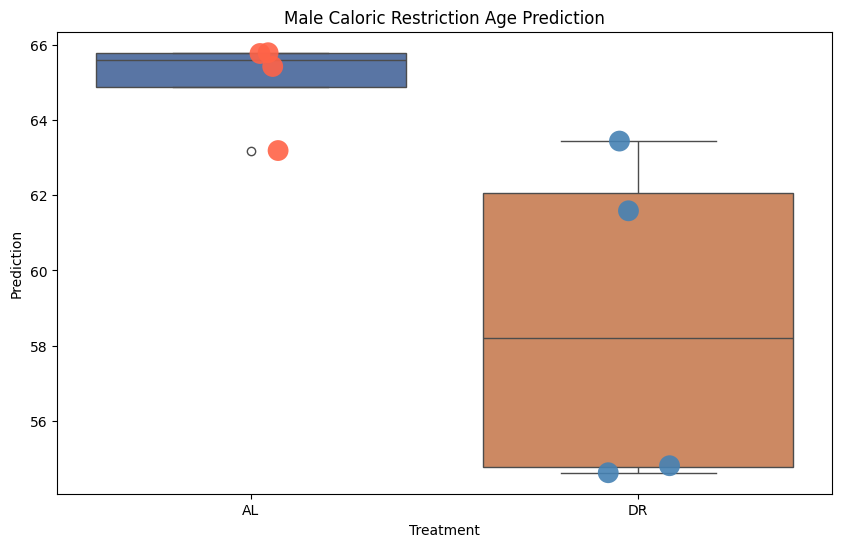

In [ ]:
# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='treatment', y='y_pred', hue='treatment', data=df_cr, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='treatment',
    y='y_pred',
    hue='treatment',
    data=df_cr,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Male Caloric Restriction Age Prediction')
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

# Show the plot
plt.show()

### Female

In [ ]:
df_cr_age_liver_female = df_cr_age_liver[df_cr_age_liver["sex"] == "f"]

df_cr_age_liver_female.head(5)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,treatment,tissue,sex
f_AL_L_1,1.065663,1.065663,2.131327,188.622436,152.389878,9.590971,1.065663,101.238031,411.346104,902.616968,...,822.692207,3.196990,596.771549,1.065663,22.378933,41.560876,83.121752,AL,Liver,f
f_AL_L_2,1.682535,1.682535,1.682535,11.777742,215.364425,5.047604,5.047604,31.968157,464.379542,792.473784,...,1068.409454,5.047604,329.776776,1.682535,45.428433,8.412673,42.063364,AL,Liver,f
f_DR_L_1,0.826384,0.826384,0.826384,15.701294,376.831063,32.228973,0.826384,123.131203,187.589148,2644.428513,...,2487.415570,0.826384,379.310215,14.048526,14.048526,12.395759,13.222143,DR,Liver,f
f_DR_L_2,1.071467,1.071467,1.071467,39.644275,259.294991,26.786673,1.071467,155.362701,296.796332,1856.852144,...,2045.430319,7.500268,326.797406,9.643202,22.500805,5.357335,78.217084,DR,Liver,f
f_AL_L_3,1.053069,1.053069,1.053069,35.804344,354.884231,9.477620,5.265345,118.996790,223.250614,1613.301608,...,1268.948067,5.265345,390.688575,11.583758,26.326723,7.371483,63.184136,AL,Liver,f


In [ ]:
df_cr_age_liver_female = df_cr_age_liver_female.iloc[:,:-3]

df_cr_age_liver_female.head(5)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,LOC107393324,chp1,LOC107392884,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249
f_AL_L_1,1.065663,1.065663,2.131327,188.622436,152.389878,9.590971,1.065663,101.238031,411.346104,902.616968,...,3.196990,1459.958969,1.065663,822.692207,3.196990,596.771549,1.065663,22.378933,41.560876,83.121752
f_AL_L_2,1.682535,1.682535,1.682535,11.777742,215.364425,5.047604,5.047604,31.968157,464.379542,792.473784,...,1.682535,5838.394970,1.682535,1068.409454,5.047604,329.776776,1.682535,45.428433,8.412673,42.063364
f_DR_L_1,0.826384,0.826384,0.826384,15.701294,376.831063,32.228973,0.826384,123.131203,187.589148,2644.428513,...,0.826384,1765.982416,0.826384,2487.415570,0.826384,379.310215,14.048526,14.048526,12.395759,13.222143
f_DR_L_2,1.071467,1.071467,1.071467,39.644275,259.294991,26.786673,1.071467,155.362701,296.796332,1856.852144,...,1.071467,1749.705454,1.071467,2045.430319,7.500268,326.797406,9.643202,22.500805,5.357335,78.217084
f_AL_L_3,1.053069,1.053069,1.053069,35.804344,354.884231,9.477620,5.265345,118.996790,223.250614,1613.301608,...,1.053069,5136.870264,1.053069,1268.948067,5.265345,390.688575,11.583758,26.326723,7.371483,63.184136


In [ ]:
df_cr_age_liver_female_norm = df_cr_age_liver_female.copy()

In [ ]:
df_cr_age_liver_female_norm["age"] = 63

df_cr_age_liver_female_norm.head(5)

,LOC107375582,LOC107388276,LOC107382448,LOC107377727,pex1,LOC107393665,LOC107377394,zbtb41,LOC107377691,tuba4a,...,chp1,LOC107392884,LOC107372821,LOC107386901,LOC107386251,LOC107378151,dag1,LOC107396310,LOC107378249,age
f_AL_L_1,1.065663,1.065663,2.131327,188.622436,152.389878,9.590971,1.065663,101.238031,411.346104,902.616968,...,1459.958969,1.065663,822.692207,3.196990,596.771549,1.065663,22.378933,41.560876,83.121752,63
f_AL_L_2,1.682535,1.682535,1.682535,11.777742,215.364425,5.047604,5.047604,31.968157,464.379542,792.473784,...,5838.394970,1.682535,1068.409454,5.047604,329.776776,1.682535,45.428433,8.412673,42.063364,63
f_DR_L_1,0.826384,0.826384,0.826384,15.701294,376.831063,32.228973,0.826384,123.131203,187.589148,2644.428513,...,1765.982416,0.826384,2487.415570,0.826384,379.310215,14.048526,14.048526,12.395759,13.222143,63
f_DR_L_2,1.071467,1.071467,1.071467,39.644275,259.294991,26.786673,1.071467,155.362701,296.796332,1856.852144,...,1749.705454,1.071467,2045.430319,7.500268,326.797406,9.643202,22.500805,5.357335,78.217084,63
f_AL_L_3,1.053069,1.053069,1.053069,35.804344,354.884231,9.477620,5.265345,118.996790,223.250614,1613.301608,...,5136.870264,1.053069,1268.948067,5.265345,390.688575,11.583758,26.326723,7.371483,63.184136,63


In [ ]:
liver_df_female = liver_df.loc[liver_df.iloc[:,-3] == "F"]

In [ ]:
liver_df_female["age_days"].value_counts()

age_days
52     2
133    2
102    2
134    2
147    2
78     2
47     2
49     2
75     2
155    2
77     2
103    1
Name: count, dtype: int64

In [ ]:
liver_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114,F,Liver,52
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717,F,Liver,133
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056,F,Liver,102
B6_1,52010.405793,439.314180,3444.223173,593.074143,74.683411,1107.071734,926.952920,1555.172198,760.013532,733.654681,...,39.538276,3088.378687,4.393142,487.638740,1871.478408,505.211307,544.749583,F,Liver,134
B8_1,57870.342592,385.596632,4719.702781,704.356515,66.836750,776.334553,1033.398975,1269.898243,1043.681552,622.095900,...,87.401903,2035.950219,35.989019,493.563689,1300.745973,426.726940,483.281113,F,Liver,133


In [ ]:
liver_df_female.shape

(23, 25125)

In [ ]:
age_days_value_counts = liver_df_female["age_days"].value_counts().index.tolist()

print(sorted(age_days_value_counts))

[47, 49, 52, 75, 77, 78, 102, 103, 133, 134, 147, 155]


In [ ]:
liver_gene_expression_data_female = liver_df_female.iloc[:, :-3]

In [ ]:
liver_df_female_age = liver_gene_expression_data_female.copy()

liver_df_female_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,181.117195,191.616742,1007.956563,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,140.536893,202.236017,1336.814350,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,118.498749,157.998332,1116.760935,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056


In [ ]:
liver_df_female_age["age"] = liver_df_female["age_days"].tolist()

liver_df_female_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,191.616742,1007.956563,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114,52
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,202.236017,1336.814350,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717,133
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,157.998332,1116.760935,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056,102


In [ ]:
# Find common columns between the two DataFrames
common_columns = liver_df_female_age.columns.intersection(df_cr_age_liver_female_norm.columns)

# Select only the common columns from both DataFrames
liver_df_female_age_common = liver_df_female_age[common_columns]
df_cr_age_liver_female_norm_common = df_cr_age_liver_female_norm[common_columns]

# Concatenate the DataFrames with the same columns
liver_df_female_cr_female = pd.concat([liver_df_female_age_common, df_cr_age_liver_female_norm_common], axis=0)

In [ ]:
liver_df_female_cr_female.head(10)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,191.616742,1007.956563,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114,52
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,202.236017,1336.814350,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717,133
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,157.998332,1116.760935,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056,102
B6_1,52010.405793,439.314180,3444.223173,593.074143,74.683411,1107.071734,926.952920,1555.172198,760.013532,733.654681,...,101.042261,856.662651,39.538276,3088.378687,4.393142,487.638740,1871.478408,505.211307,544.749583,134
B8_1,57870.342592,385.596632,4719.702781,704.356515,66.836750,776.334553,1033.398975,1269.898243,1043.681552,622.095900,...,303.336017,925.431918,87.401903,2035.950219,35.989019,493.563689,1300.745973,426.726940,483.281113,133
C6_1,47984.562591,858.602909,19799.707089,605.882053,55.080187,1046.523546,1072.443634,1389.964710,1590.845390,686.882327,...,90.720307,1130.763831,106.920362,2361.968003,178.200604,320.761087,2089.807081,631.802141,476.281614,52
D7_1,67424.185356,556.809238,15745.327910,796.546549,73.467886,931.882128,1179.352901,1871.497718,804.280011,479.474622,...,143.069040,912.548474,92.801540,1600.826561,27.067116,634.143855,2002.966566,421.473660,545.209046,147
E6_1,63081.109900,597.464257,6752.735553,719.736012,141.724080,947.606100,928.153776,1297.747944,1217.159742,603.022064,...,69.472588,975.395135,97.261623,1267.180005,25.010132,408.498817,2576.043563,464.076888,408.498817,134
E8_1,54598.001812,466.518856,3303.871240,783.904635,57.358876,1166.297139,1284.838816,1636.639920,944.509486,676.834733,...,156.780927,936.861636,110.893826,1781.949072,19.119625,416.807830,2588.797256,558.293057,439.751380,147
G5_1,49741.618891,708.784412,8291.589712,633.550312,75.234100,1243.342488,1211.664972,1381.931619,1136.430873,601.872797,...,340.533293,1104.753357,83.153478,2213.466403,91.072857,542.477455,1987.764105,673.147207,344.492982,78


In [ ]:
liver_df_female_cr_female.tail(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
f_DR_L_2,12065.788803,336.440608,971.820482,384.656618,33.215474,828.243917,277.509928,607.521734,909.675401,551.805455,...,171.434705,93.217621,90.003220,1175.399193,55.716279,132.861896,687.881752,93.217621,78.217084,63
f_AL_L_3,14199.581518,215.879132,1926.063082,507.579227,91.616997,859.304251,280.116337,937.231352,720.299151,605.514638,...,106.359962,128.474410,146.376582,1731.245329,97.935411,190.605477,566.551087,58.971860,137.952030,63
f_AL_L_4,21929.749431,61.612153,3024.216874,553.465105,88.763272,410.399596,198.412019,829.153383,360.274455,626.564269,...,61.612153,133.667044,154.552520,342.521801,5.221369,158.729615,715.327541,28.195392,63.700701,63
f_DR_L_3,14328.232746,130.359217,1402.615033,727.003324,53.898522,488.847062,273.252973,780.901846,686.892795,432.441632,...,180.497377,91.502142,142.893757,1144.403508,40.110528,236.902807,369.768932,8.774178,48.884706,63
f_DR_L_4,15578.303085,151.029693,451.918307,565.483270,36.293957,447.235216,229.471472,840.614882,484.699946,446.064443,...,197.860606,200.202151,80.783324,1382.682695,1.170773,112.394190,558.458633,83.124870,105.369553,63


In [ ]:
data = liver_df_female_cr_female.values

In [ ]:
X, y = data[:,:-1], data[:,-1]

y

array([ 52., 133., 102., 134., 133.,  52., 147., 134., 147.,  78.,  47.,
        47.,  78.,  49.,  49.,  75.,  75., 155., 155.,  77.,  77., 102.,
       103.,  63.,  63.,  63.,  63.,  63.,  63.,  63.,  63.])

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.493e+00, tolerance: 3.937e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.253e+00, tolerance: 3.744e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitt

Best parameters found:  {'alpha': 0.01, 'l1_ratio': 1.0}
MAE: 17.074
Pearson correlation: 0.826
R-squared: 0.678


In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):

    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=0.01, l1_ratio=1.0, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 17.074
Pearson correlation: 0.826
R-squared: 0.678
Average number of non-zero coefficients: 41.58


In [ ]:
# Create a DataFrame
df = pd.DataFrame({
    'y_true': y_true,
    'y_pred': y_pred
}, index=liver_df_female_cr_female.index.tolist())

df.head(10)

,y_true,y_pred
A6_1,52.0,59.275076
A7_1,133.0,112.096399
B5_1,102.0,105.239623
B6_1,134.0,119.512703
B8_1,133.0,108.494837
C6_1,52.0,66.695658
D7_1,147.0,129.376183
E6_1,134.0,163.715521
E8_1,147.0,110.599858
G5_1,78.0,102.279534


In [ ]:
df_cr = df.loc[df_cr_age_liver_female.index.tolist(), ]

df_cr.head(5)

,y_true,y_pred
f_AL_L_1,63.0,77.518107
f_AL_L_2,63.0,53.873399
f_DR_L_1,63.0,53.210263
f_DR_L_2,63.0,64.739096
f_AL_L_3,63.0,71.598455


In [ ]:
df_cr["treatment"] = df_cr_age_liver["treatment"]

df_cr.head(5)

,y_true,y_pred,treatment
f_AL_L_1,63.0,77.518107,AL
f_AL_L_2,63.0,53.873399,AL
f_DR_L_1,63.0,53.210263,DR
f_DR_L_2,63.0,64.739096,DR
f_AL_L_3,63.0,71.598455,AL


In [ ]:
df_cr.to_csv("./df_prediction_sex_specific_mckay_female.csv", sep="\t")

In [ ]:
from scipy.stats import ttest_ind, mannwhitneyu

In [ ]:
# Ensure predictions are numeric
pred_al = pd.to_numeric(df_cr[df_cr['treatment'] == "AL"]['y_pred'], errors='coerce')
pred_dr = pd.to_numeric(df_cr[df_cr['treatment'] == "DR"]['y_pred'], errors='coerce')

# Drop any NaN values if necessary
pred_al = pred_al.dropna()
pred_dr = pred_dr.dropna()

# Perform t-test
t_stat, p_ttest = ttest_ind(pred_al, pred_dr, equal_var=False)  # Welch's t-test for unequal variances

# Perform Mann-Whitney U test
u_stat, p_mwu = mannwhitneyu(pred_al, pred_dr, alternative='two-sided')

# Print results
print(f"T-test p-value: {p_ttest}")
print(f"Mann-Whitney U test p-value: {p_mwu}")

T-test p-value: 0.2545006549301825
Mann-Whitney U test p-value: 0.34285714285714286


In [ ]:
# Filter the DataFrame to include only rows where true_age is 105
filtered_df_al = df_cr[df_cr['treatment'] == "AL"]
filtered_df_dr = df_cr[df_cr['treatment'] == "DR"]

# Display the filtered DataFrame
print(filtered_df_al)

          y_true     y_pred treatment
f_AL_L_1    63.0  77.518107        AL
f_AL_L_2    63.0  53.873399        AL
f_AL_L_3    63.0  71.598455        AL
f_AL_L_4    63.0  64.654338        AL


/tmp/ipykernel_109618/3188165410.py:12: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  strip = sns.stripplot(


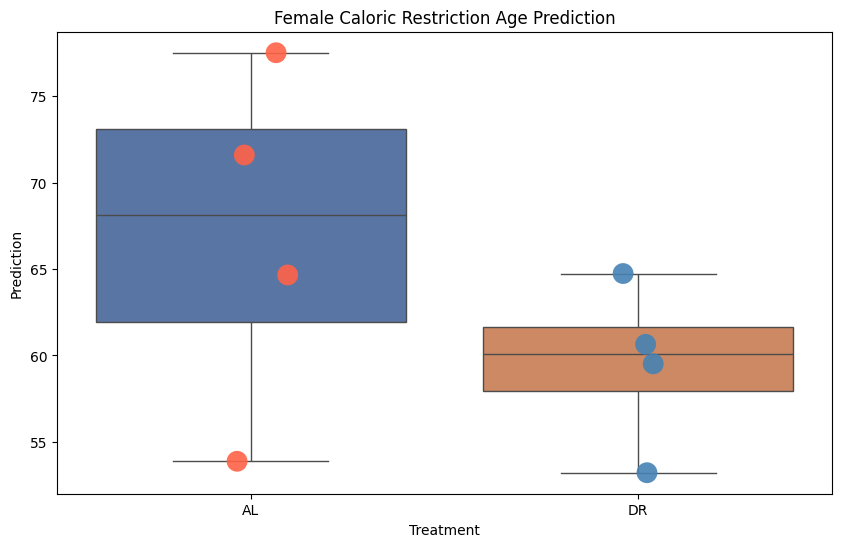

In [ ]:
# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='treatment', y='y_pred', hue='treatment', data=df_cr, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='treatment',
    y='y_pred',
    hue='treatment',
    data=df_cr,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Female Caloric Restriction Age Prediction')
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)


# Show the plot
plt.show()